### **Linear SVM-based classification with n-grams**

This notebook implements a text classification using a Linear SVM and TFIDF vectorization. To identify the most robust linguistic representation, various feature extraction strategies are compared, including raw word forms, normalized lemmas, POS tags, and character ngrams, using 5 fold Cross Validation on the training data. The best performing configuration is then retrained on the full training set and evaluated on the unseen Validation and Test sets. Finally, the evaluation is enriched with visual diagnostics, such as Confusion Matrix, ROC, and Precision-Recall curves, alongside a dedicated overfitting analysis comparing Hinge Loss and Macro-F1 scores across data splits to ensure the model's generalization capabilities.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import hinge_loss, f1_score

from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

### Data loading

In [2]:
# Load the processed dataframes using the correct paths
df_train = pd.read_pickle("../data/enriched/train_final.pkl")
df_val = pd.read_pickle("../data/enriched/val_final.pkl")  
df_test = pd.read_pickle("../data/enriched/test_final.pkl")

# Extract the target vectors
y_train = df_train['label'].copy()
y_val = df_val['label'].copy()
y_test = df_test['label'].copy()

print(f"Train shape: {df_train.shape}")
print(f"Validation shape: {df_val.shape}")
print(f"Test shape: {df_test.shape}\n")

Train shape: (4000, 147)
Validation shape: (2000, 147)
Test shape: (2000, 147)



### Defining the configurations
The following dictionary outlines the experimental configurations used to build the TF-IDF feature matrices. By systematically varying the linguistic level (word forms, lemmas, POS tags, and characters) alongside different n-gram ranges, these configurations aim to identify the most effective textual representation for distinguishing between human and machine-generated text.

In [3]:
configs = {
    # WORD FORMS (TOKENS)
    "word_forms_unigrams": {
        "column": "text",
        "analyzer": "word",
        "ngram_range": (1, 1)
    },
    "word_forms_unigrams_bigrams": {
        "column": "text",
        "analyzer": "word",
        "ngram_range": (1, 2)
    },
    
    # LEMMAS
    "lemmas_unigrams": {
        "column": "lemmas_processed",
        "analyzer": "word",
        "ngram_range": (1, 1)
    },
    "lemmas_bigrams": {
        "column": "lemmas_processed",
        "analyzer": "word",
        "ngram_range": (1, 2)
    },
    
    # POS TAGS
    "pos_bigrams": {
        "column": "pos_processed",
        "analyzer": "word",
        "ngram_range": (2, 2)
    },
    "pos_trigrams": {
        "column": "pos_processed",
        "analyzer": "word",
        "ngram_range": (3, 3)
    },
    
    # CHARACTERS
    "characters_3_5_grams": {
        "column": "text",
        "analyzer": "char",
        "ngram_range": (3, 5)
    }
}

### Model Selection via Cross-Validation
In this section, each linguistic configuration is evaluated alongside various values of the SVM regularization parameter (C) using a 5-fold cross-validation on the training set. A Scikit-Learn Pipeline is employed to chain the TfidfVectorizer and the LinearSVC, ensuring robust evaluation and preventing data leakage across folds. The models are compared based on their average Macro F1-score to systematically identify both the best-performing textual representation and the optimal regularization strength.

In [4]:
best_score = 0
best_config_name = None
best_params = None
best_c = None

# Define the C values to test for the SVM regularization
c_values = [0.001,0.01, 0.1, 1.0, 10.0]

# Iterate over each configuration defined in the 'configs' dictionary
for config_name, params in configs.items():
    
    # Iterate over each C value for the current configuration
    for c_val in c_values:
        
        pipeline = Pipeline([
            ("tfidf", TfidfVectorizer(
                analyzer=params["analyzer"], 
                ngram_range=params["ngram_range"], 
                min_df=5 
            )),
            # dual=False is preferred when n_samples > n_features for LinearSVC
            ("clf", LinearSVC(C=c_val, random_state=42, dual=False, max_iter=2000))
        ])

        # Evaluation via 5-fold cross-validation
        scores = cross_val_score(
            pipeline,
            df_train[params["column"]], 
            y_train,
            cv=5,
            scoring="f1_macro",
            n_jobs=-1
        )

        mean_score = np.mean(scores)
        print(f"Config: {config_name} | C: {c_val}")
        print(f"Mean Macro-F1: {mean_score:.4f}\n")
        
        if mean_score > best_score:
            best_score = mean_score
            best_config_name = config_name
            best_params = params
            best_c = c_val

print(f"*** Best Configuration: {best_config_name} with C={best_c} (Macro-F1: {best_score:.4f}) ***\n")

Config: word_forms_unigrams | C: 0.001
Mean Macro-F1: 0.9322

Config: word_forms_unigrams | C: 0.01
Mean Macro-F1: 0.9444

Config: word_forms_unigrams | C: 0.1
Mean Macro-F1: 0.9752

Config: word_forms_unigrams | C: 1.0
Mean Macro-F1: 0.9857

Config: word_forms_unigrams | C: 10.0
Mean Macro-F1: 0.9860

Config: word_forms_unigrams_bigrams | C: 0.001
Mean Macro-F1: 0.9532

Config: word_forms_unigrams_bigrams | C: 0.01
Mean Macro-F1: 0.9632

Config: word_forms_unigrams_bigrams | C: 0.1
Mean Macro-F1: 0.9810

Config: word_forms_unigrams_bigrams | C: 1.0
Mean Macro-F1: 0.9885

Config: word_forms_unigrams_bigrams | C: 10.0
Mean Macro-F1: 0.9892

Config: lemmas_unigrams | C: 0.001
Mean Macro-F1: 0.8471

Config: lemmas_unigrams | C: 0.01
Mean Macro-F1: 0.8921

Config: lemmas_unigrams | C: 0.1
Mean Macro-F1: 0.9575

Config: lemmas_unigrams | C: 1.0
Mean Macro-F1: 0.9825

Config: lemmas_unigrams | C: 10.0
Mean Macro-F1: 0.9815

Config: lemmas_bigrams | C: 0.001
Mean Macro-F1: 0.8456

Config: lem

### Final Training and Evaluation
Having identified the optimal textual representation, the best configuration is now retrained on the entire training set. The model's performance is subsequently evaluated across the Training, Validation, and Test sets to assess its generalization capabilities and rule out overfitting. Finally, a confusion matrix is plotted to visualize the error distribution on the unseen Test set.


=== Train Set Evaluation ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2000
           1       1.00      1.00      1.00      2000

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000

=== Validation Set Evaluation ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1000
           1       0.99      0.99      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000

=== Test Set Evaluation ===
              precision    recall  f1-score   support

           0       0.80      0.99      0.88      1000
           1       0.99      0.75      0.85      1000

    accuracy                           0.87      2000
   macro avg       0.89      0.87   

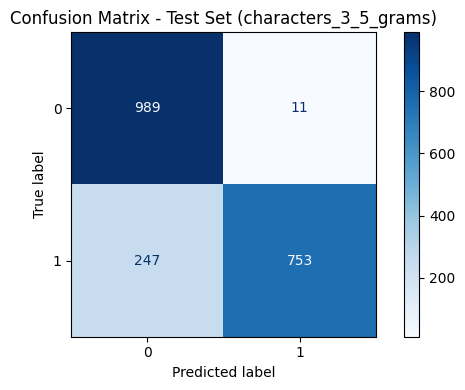

In [5]:
# Initialize the optimal pipeline
best_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer=best_params["analyzer"], 
        ngram_range=best_params["ngram_range"], 
        min_df=5
    )),
    ("clf", LinearSVC(C=best_c, random_state=42, dual=False, max_iter=2000))
])

# Train on the training set using the best column
best_column = best_params["column"]
best_pipeline.fit(df_train[best_column], y_train)

# Predictions on the three splits
pred_train = best_pipeline.predict(df_train[best_column])
pred_val = best_pipeline.predict(df_val[best_column])
pred_test = best_pipeline.predict(df_test[best_column])

# Print the classification reports
print("\n=== Train Set Evaluation ===")
print(classification_report(y_train, pred_train, zero_division=0))

print("=== Validation Set Evaluation ===")
print(classification_report(y_val, pred_val, zero_division=0))

print("=== Test Set Evaluation ===")
print(classification_report(y_test, pred_test, zero_division=0))

# Generate the confusion matrix on the test set
cm = confusion_matrix(y_test, pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_pipeline.classes_)

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=0)
plt.title(f"Confusion Matrix - Test Set ({best_config_name})")
plt.tight_layout()
plt.show()

### ROC and PR curve 

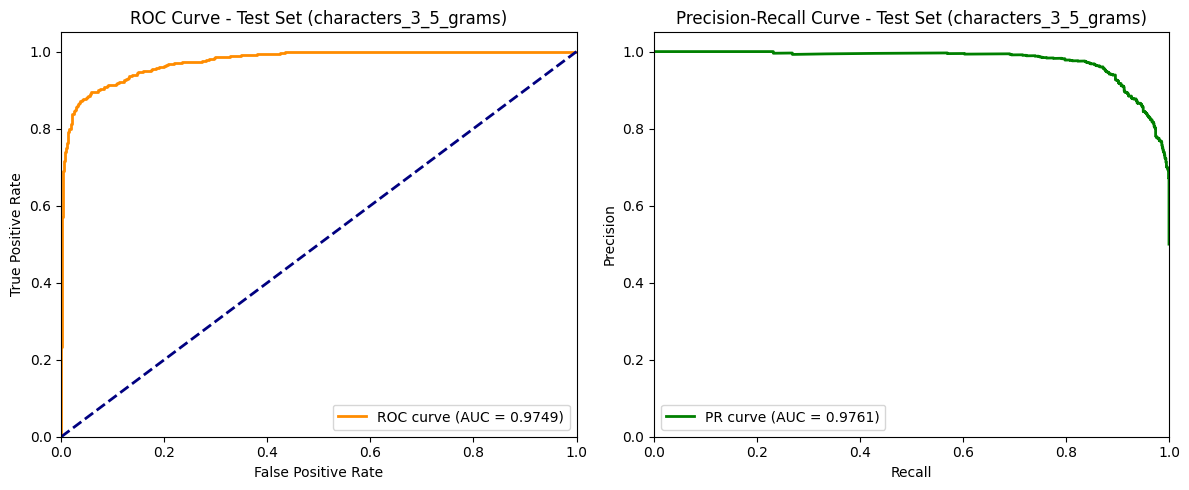

In [6]:
y_scores = best_pipeline.decision_function(df_test[best_column])

# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Receiver Operating Characteristic (ROC) Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal guessing line
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title(f'ROC Curve - Test Set ({best_config_name})')
ax1.legend(loc="lower right")

# Precision-Recall (PR) Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_scores)
pr_auc = average_precision_score(y_test, y_scores)

ax2.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title(f'Precision-Recall Curve - Test Set ({best_config_name})')
ax2.legend(loc="lower left")

# Adjust layout and display
plt.tight_layout()
plt.show()

### Overfitting Diagnostics
To thoroughly verify whether the optimized model generalizes effectively across unseen data, an overfitting analysis is conducted by evaluating performance across the Training, Validation, and Test sets. By computing both the Hinge Loss and the Macro-F1 score, we monitor any potential performance drop. The results are compiled into a comprehensive DataFrame and paired with an automated diagnostic check and a comparative bar chart to visually highlight the model's robustness.


--- Overfitting & Generalization Analysis ---


,Metric,Training,Validation,Test
0,Hinge Loss (Lower is better),0.0085,0.1319,0.3635
1,Macro-F1 (Higher is better),1.0000,0.9910,0.8692



--- Interpretation ---
Good: The gap between Training and Validation scores is minimal.
The model generalizes well and does not show severe signs of overfitting.



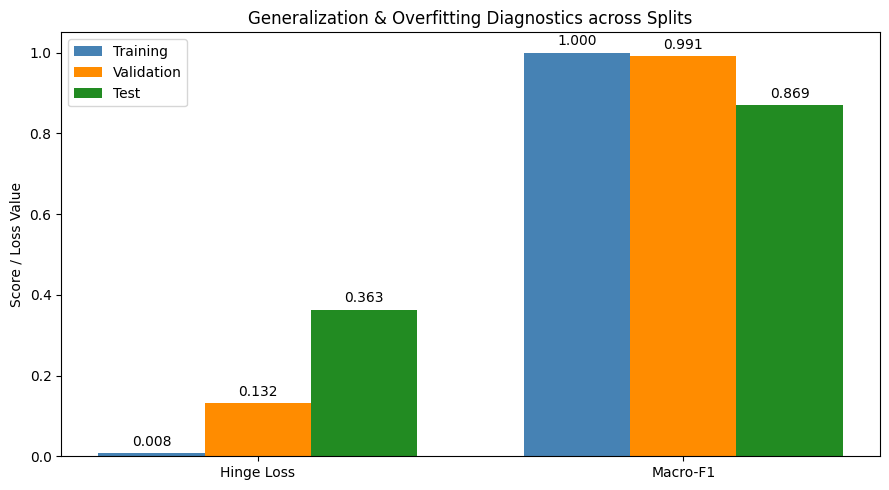

In [7]:
print("\n--- Overfitting & Generalization Analysis ---")

# Extract the decision function scores across all three splits
dec_train = best_pipeline.decision_function(df_train[best_column])
dec_val = best_pipeline.decision_function(df_val[best_column])
dec_test = best_pipeline.decision_function(df_test[best_column])

# Hinge loss requires numeric targets {-1, 1}
# The classes are dynamically mapped based on the pipeline's detected classes
positive_class = best_pipeline.classes_[1]
y_train_num = np.where(y_train == positive_class, 1, -1)
y_val_num = np.where(y_val == positive_class, 1, -1)
y_test_num = np.where(y_test == positive_class, 1, -1)

# Calculate Hinge Loss for all splits
loss_train = hinge_loss(y_train_num, dec_train)
loss_val = hinge_loss(y_val_num, dec_val)
loss_test = hinge_loss(y_test_num, dec_test)

# Calculate Macro-F1 Score for all splits
f1_train = f1_score(y_train, pred_train, average='macro')
f1_val = f1_score(y_val, pred_val, average='macro')
f1_test = f1_score(y_test, pred_test, average='macro')

# Structure the results in a DataFrame for clean visualization
overfitting_data = [
    {"Metric": "Hinge Loss (Lower is better)", "Training": loss_train, "Validation": loss_val, "Test": loss_test},
    {"Metric": "Macro-F1 (Higher is better)", "Training": f1_train, "Validation": f1_val, "Test": f1_test}
]

df_overfitting = pd.DataFrame(overfitting_data).round(4)
display(df_overfitting)

# Provide an automated interpretation based on the Training-Validation F1 Gap
f1_gap = f1_train - f1_val
print("\n--- Interpretation ---")
if f1_gap > 0.15:
    print("Warning: A significant gap between Training and Validation scores is detected (F1 Gap > 0.15).")
    print("This suggests the model might be overfitting the training data.")
elif f1_gap < -0.05:
    print("Notice: Validation score is notably higher than Training score. Check data distribution.")
else:
    print("Good: The gap between Training and Validation scores is minimal.")
    print("The model generalizes well and does not show severe signs of overfitting.\n")

# Graphical Visualization (Comparative Bar Chart for Train, Val, Test)
metrics = ['Hinge Loss', 'Macro-F1']
train_scores = [loss_train, f1_train]
val_scores = [loss_val, f1_val]
test_scores = [loss_test, f1_test]

x = np.arange(len(metrics)) 
width = 0.25  

fig, ax = plt.subplots(figsize=(9, 5))
rects1 = ax.bar(x - width, train_scores, width, label='Training', color='steelblue')
rects2 = ax.bar(x, val_scores, width, label='Validation', color='darkorange')
rects3 = ax.bar(x + width, test_scores, width, label='Test', color='forestgreen')

ax.set_ylabel('Score / Loss Value')
ax.set_title('Generalization & Overfitting Diagnostics across Splits')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')
ax.bar_label(rects3, padding=3, fmt='%.3f')

plt.tight_layout()
plt.show()